In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from numpy.lib.stride_tricks import sliding_window_view

In [6]:
#Creating the function for time and our wave equation
def time_axis(fs, duration):
    T = 1/fs
    return np.arange(0, duration, T)
def wave_equation(f, t, A = 1, p = 0):
    return A*np.sin(2*np.pi*f*t + p)

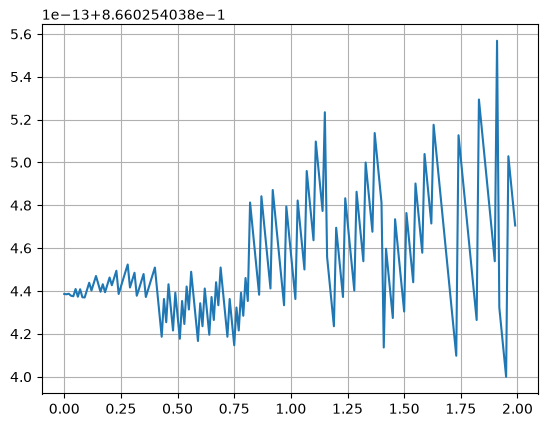

In [7]:
# aliasing : fs >= 2f
fs = 100
f = 100
duration = 2
A = 1
p = np.pi/3
t = time_axis(fs, duration)
y = wave_equation(f, t, A, p)
plt.plot(t, y)
plt.grid()

In [5]:
# sd.play(y, fs)
# sd.wait()

In [35]:
from IPython.display import Audio

# Play audio directly in notebook
Audio(y, rate=fs)

2000


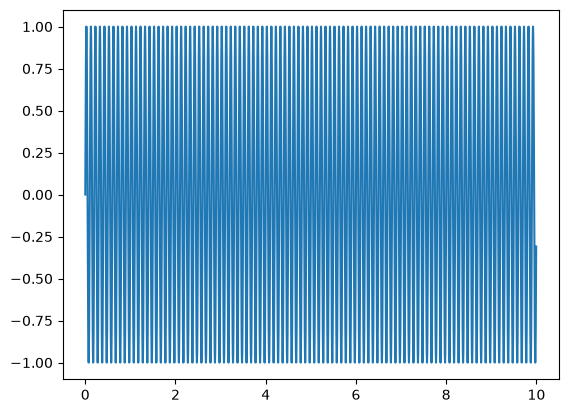

In [41]:
time = time_axis(200, 10)
y = wave_equation(10, time, 1, 0)
# numbers of samples we get using fs = 200 with duration = 10s
print(len(y))
plt.plot(time, y)

200


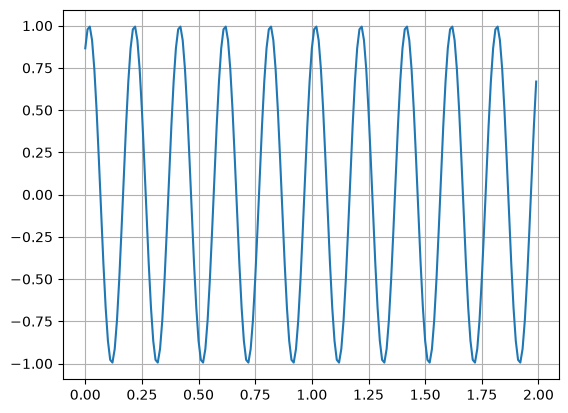

In [8]:
fs = 100
f = 5
duration = 2
A = 1
p = np.pi/3
t = time_axis(fs, duration)
y = wave_equation(f, t, A, p)
print(len(y))
plt.plot(t, y)
plt.grid()

20
19


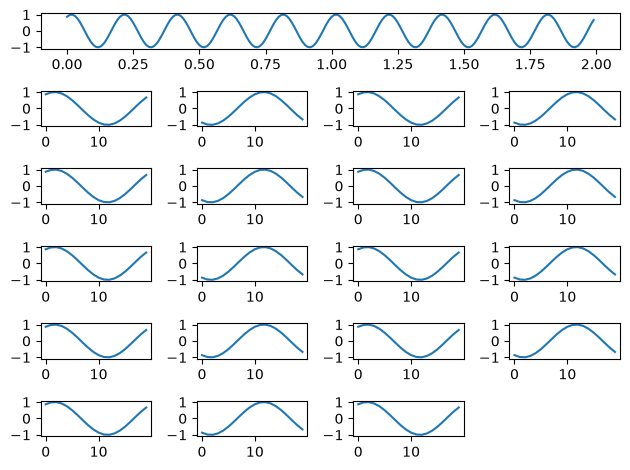

In [17]:
#using the direct ways to solve
N = fs * duration
L = int((1/f)*fs)
print(L)
H = int(0.5*L)
start_sample = 0
end_sample = L

num_frame = 1 + (N - L)//H
print(num_frame)
plt.subplot(6, 1, 1)
plt.plot(t, y)
for i in range(1, num_frame+1):
    # print(i)
    y_window = y[start_sample:end_sample]
    plt.subplot(6, 4, i+4)
    plt.plot(y_window)
    start_sample += H
    end_sample += H

plt.tight_layout()

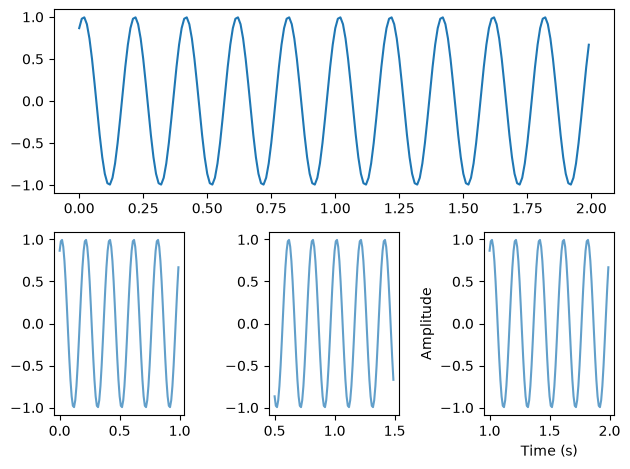

In [75]:
# what is this ? don't know if it's right or wrong. can be wrong more than right
#using sliding_window_view from numpy- different approach same result
L = 100
H = int(0.5*L)
windows = sliding_window_view(y, window_shape = L)
windows = windows[::H]
frame_time_axis = np.arange(L) / fs
plt.subplot(2, 1, 1)
plt.plot(t, y)
for i in range(min(5, len(windows))):  # Only plot first 5 frames
    start_time = i * H / fs
    time_axis = frame_time_axis + start_time  # Shift the frame to its correct time
    plt.subplot(2, 3, i+4)
    plt.plot(time_axis, windows[i], alpha=0.7, label=f'Frame {i+1}')
    # print(i)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()